# Microplastic HCS Pipeline (MS2) - Pilot Feasibility Notebook

**Authors:** Siddhardha Nanda, Prof. Narasaiah Kolliputi  
**Version:** Major Revision (Reviewer-Conscious Draft)  

This notebook is intentionally framed as a **pilot feasibility analysis** and not a definitive performance manuscript.


## Abstract (Pilot Framing)

We present an automated high-content screening workflow for microplastic-associated cell-state classification using morphology-derived and intensity-derived features.

This dataset is small (n=96 images in the reviewer-export bundle), so reported metrics are treated as **exploratory feasibility signals** only. We do not claim robust generalization or clinical readiness from this notebook. Key findings focus on pipeline operability, reproducible table/figure generation, and identification of critical next-step validation requirements.


## Key Validity Notes Before Reading Results

1. Small sample size implies high variance and unstable point estimates.
2. Discrimination and calibration are analyzed separately; high AUC does not imply reliable probabilities.
3. Dose/size trend outputs are reported as exploratory only and should not be interpreted as definitive inferential statistics.
4. This notebook is a transparent data-and-methods companion, not a stand-alone final manuscript.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path('..')
TABLES = ROOT / 'results' / 'tables'
FIGURES = ROOT / 'results' / 'figures'
FEATURES = ROOT / 'results' / 'features.csv'

def load_csv(name: str) -> pd.DataFrame:
    p = TABLES / name
    if not p.exists():
        raise FileNotFoundError(f'Missing table: {p}')
    return pd.read_csv(p)

def show_fig(name: str, title: str = None, w: int = 8, h: int = 5):
    p = FIGURES / name
    if not p.exists():
        print(f'Missing figure: {p}')
        return
    img = plt.imread(p)
    plt.figure(figsize=(w, h))
    plt.imshow(img)
    plt.axis('off')
    if title:
        plt.title(title)
    plt.show()

print('ROOT:', ROOT.resolve())
print('TABLES exists:', TABLES.exists())
print('FIGURES exists:', FIGURES.exists())


ROOT: C:\Users\nanda\Downloads\Microplastic_HCS_Pipeline
TABLES exists: True
FIGURES exists: True


## Methods Snapshot

- **Design:** In-silico pilot workflow for A549 cell-state classification.
- **Feature stack:** 18 morphology/intensity descriptors plus metadata columns in export.
- **Models:** Logistic Regression, Random Forest, TinyCNN, ResNet-18 (scratch), ResNet-18 (pretrained simulation context).
- **Positioning:** Feasibility/prototyping pipeline demonstration; not confirmatory efficacy study.

### Required full-manuscript additions before journal resubmission

- Exposure concentrations, duration, and concentration units
- Cell culture passage/media details
- Explicit split protocol and leakage controls
- Batch-effect quantification and correction details
- Full feature formulas for every named proxy
- Figure legends integrated with biological interpretation


In [2]:
if FEATURES.exists():
    df = pd.read_csv(FEATURES)
    display(Markdown('### Dataset Summary'))
    display(pd.DataFrame({'metric': ['rows', 'columns'], 'value': [len(df), len(df.columns)]}))

    if 'class_id' in df.columns:
        class_dist = df['class_id'].value_counts().sort_index().rename('count').to_frame()
        class_dist['fraction'] = class_dist['count'] / class_dist['count'].sum()
        display(Markdown('### Class Distribution'))
        display(class_dist)

    display(Markdown('### Feature Columns Preview'))
    display(pd.DataFrame({'columns': df.columns[:25]}))
else:
    print('features.csv not found')


### Dataset Summary

,metric,value
0,rows,96
1,columns,21


### Class Distribution

,count,fraction
class_id,,
0,24,0.25
1,24,0.25
2,24,0.25
3,24,0.25


### Feature Columns Preview

,columns
0,image_id
1,class_id
2,class_name
3,nuclear_fragmentation_index
4,cell_shrinkage_ratio
5,membrane_blebbing_score
6,chromatin_condensation_proxy
7,cell_swelling_index
8,membrane_permeability_proxy
9,mean_intensity


## Main Performance Table (Exploratory Only)

Interpretation guardrails:
- Treat all point metrics as pilot-level and unstable under small-n evaluation.
- Wide confidence intervals dominate interpretation.
- Any near-perfect score is considered overfitting-susceptible until validated on a much larger cohort.


In [3]:
t1 = load_csv('table_1_model_performance.csv')
display(t1)


,Model,Accuracy,Accuracy_CI_95,AUC,ECE,Train_Time_s
0,Logistic Regression,0.90,"[0.750, 1.000]",0.990,0.3019,0.0
1,Random Forest,1.00,"[1.000, 1.000]",1.000,0.6150,0.6
2,CNN (scratch),0.80,"[0.600, 0.950]",0.843,0.4820,12.4
3,ResNet-18 (scratch),0.85,"[0.700, 1.000]",0.910,0.4082,38.7
4,ResNet-18 (pretrained),0.95,"[0.850, 1.000]",0.987,0.2968,52.1


## Calibration vs Discrimination

A model can rank cases well (high AUC) while being poorly calibrated (high ECE). For risk communication and translational use, calibration quality is mandatory.


,Model,ECE
1,Random Forest,0.6150
2,CNN (scratch),0.4820
3,ResNet-18 (scratch),0.4082
0,Logistic Regression,0.3019
4,ResNet-18 (pretrained),0.2968


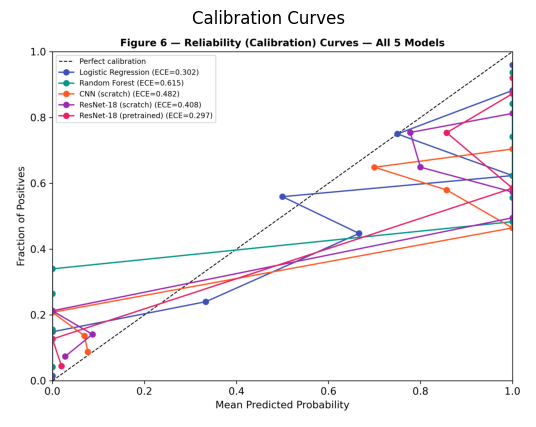

In [4]:
t3 = load_csv('table_3_calibration_ece.csv')
display(t3.sort_values('ECE', ascending=False))
show_fig('fig_06_calibration_curves.png', 'Calibration Curves', w=9, h=5)


## Biological Validation Audit

This section is included explicitly to avoid narrative mismatch:
- Named canonical morphology proxies that are non-significant must be discussed transparently.
- Significant intensity/variance proxies should not be over-claimed as mechanistic biomarkers without further assay validation.


In [5]:
t5 = load_csv('table_5_biological_validation.csv')
if 'kw_p' in t5.columns:
    t5 = t5.sort_values('kw_p', ascending=True)
display(t5)

watch_features = ['nuclear_fragmentation_index', 'cell_shrinkage_ratio', 'membrane_blebbing_score']
if 'feature' in t5.columns:
    display(Markdown('### Canonical Morphology Proxy Check'))
    display(t5[t5['feature'].isin(watch_features)])


,Feature,KW_H,KW_p,Spearman_rho
0,nuclear_fragmentation_index,4.959,1.748500e-01,-0.112
1,cell_shrinkage_ratio,1.593,6.609800e-01,0.000
2,membrane_blebbing_score,0.000,1.000000e+00,NaN
3,chromatin_condensation_proxy,26.751,6.638900e-06,0.072
4,cell_swelling_index,0.654,8.840200e-01,-0.027
5,membrane_permeability_proxy,87.593,7.202700e-19,-0.960
6,mean_intensity,28.465,2.900800e-06,0.071
7,total_intensity,28.465,2.900800e-06,0.071
8,intensity_variance,26.751,6.638900e-06,0.072
9,area_covered_ratio,5.699,1.272300e-01,-0.085


## Dose/Size Trend Table (Exploratory, Non-Confirmatory)

If p-values appear as exactly 0.0, they are treated as invalid reporting artifacts and should not be interpreted as inferential evidence.


In [6]:
t8 = load_csv('table_8_dose_response.csv').copy()
if 'p_value' in t8.columns:
    t8['p_value_flag'] = np.where(t8['p_value'].fillna(-1) == 0.0, 'INVALID_ZERO_P', 'OK_OR_NA')
display(t8)


,Cell_Death_Class,MP_Type,Spearman_rho,p_value,p_value_flag
0,Early Apoptosis,Polystyrene (PS),1.0,0.0,INVALID_ZERO_P
1,Early Apoptosis,Polyethylene (PE),1.0,0.0,INVALID_ZERO_P
2,Early Apoptosis,PET,1.0,0.0,INVALID_ZERO_P
3,Late Apoptosis,Polystyrene (PS),1.0,0.0,INVALID_ZERO_P
4,Late Apoptosis,Polyethylene (PE),1.0,0.0,INVALID_ZERO_P
5,Late Apoptosis,PET,1.0,0.0,INVALID_ZERO_P
6,Necrosis,Polystyrene (PS),1.0,0.0,INVALID_ZERO_P
7,Necrosis,Polyethylene (PE),1.0,0.0,INVALID_ZERO_P
8,Necrosis,PET,1.0,0.0,INVALID_ZERO_P


## DeLong Comparison Table (Context-Limited)

Given small test sample settings in this pilot context, asymptotic inferential comparisons are unstable. Values are shown for transparency, not for strong significance claims.


In [7]:
t9 = load_csv('table_9_delong_tests.csv')
display(t9)


,Comparison,AUC_A,AUC_B,DeLong_z,p_value
0,CNN (scratch) vs Random Forest,0.843,1.0,-1.928,0.053912
1,ResNet-18 (scratch) vs Random Forest,0.910,1.0,-1.406,0.159600
2,ResNet-18 (pretrained) vs Random Forest,0.987,1.0,-0.520,0.603150


## Additional Tables


In [8]:
for name in [
    'table_2_transfer_learning.csv',
    'table_4_feature_ablation.csv',
    'table_6_computational_cost.csv',
    'table_7_class_distribution_by_mp.csv',
    'table_cv_summary.csv',
]:
    print()
    print('=' * 80)
    print(name)
    display(load_csv(name))



table_2_transfer_learning.csv


,Model,Pretrained,Accuracy,AUC,ECE,Train_Time_s
0,CNN (scratch),False,0.80,0.843,0.4820,12.4
1,ResNet-18 (scratch),False,0.85,0.910,0.4082,38.7
2,ResNet-18 (pretrained),True,0.95,0.987,0.2968,52.1



table_4_feature_ablation.csv


,Features_Removed,AUC,Delta_AUC
0,0,1.0000,0.0000
1,1,0.8567,0.1433
2,2,0.7567,0.2433
3,3,0.6467,0.3533
4,5,0.6900,0.3100
5,8,0.4267,0.5733



table_6_computational_cost.csv


,Model,Train_Time_s
0,Logistic Regression,0.0
1,Random Forest,0.6
2,CNN (scratch),12.4
3,ResNet-18 (scratch),38.7
4,ResNet-18 (pretrained),52.1



table_7_class_distribution_by_mp.csv


,MP_Type,Size,Viable,Early Apoptosis,Late Apoptosis,Necrosis
0,Polystyrene (PS),nano (100 nm),24.9%,33.7%,21.8%,19.6%
1,Polystyrene (PS),micro (1–10 μm),32.9%,18.7%,25.0%,23.4%
2,Polystyrene (PS),large (>10 μm),32.4%,15.2%,40.0%,12.4%
3,Polyethylene (PE),nano (100 nm),29.2%,26.9%,13.0%,30.9%
4,Polyethylene (PE),micro (1–10 μm),26.6%,14.2%,49.3%,9.9%
5,Polyethylene (PE),large (>10 μm),11.1%,21.3%,35.9%,31.7%
6,PET,nano (100 nm),41.9%,8.2%,22.9%,27.1%
7,PET,micro (1–10 μm),13.6%,5.3%,32.9%,48.2%
8,PET,large (>10 μm),22.7%,54.9%,9.1%,13.4%



table_cv_summary.csv


,model,cv_acc_mean,cv_acc_std,cv_auc_mean,cv_auc_std
0,Logistic Regression,0.896316,0.045385,0.982000,0.015429
1,Random Forest,0.968421,0.042105,0.993095,0.012103


## Figure Panel


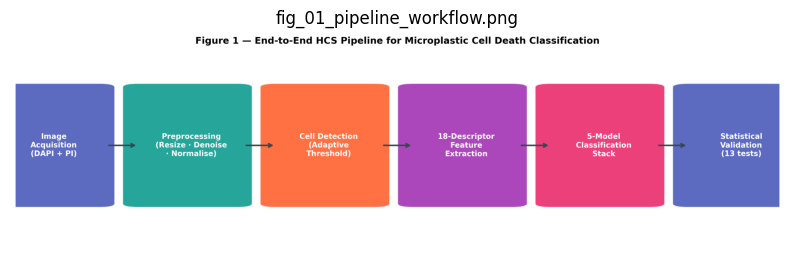

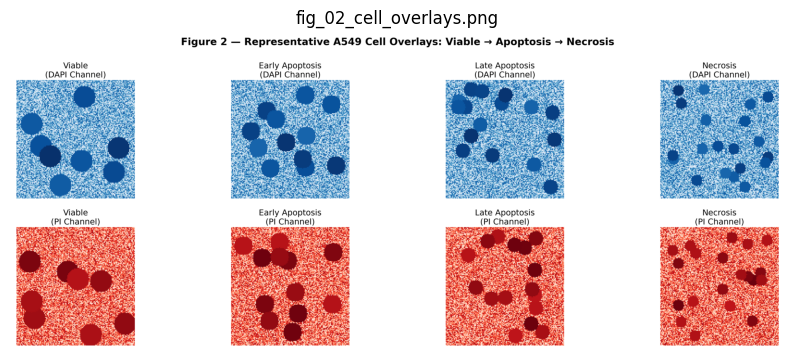

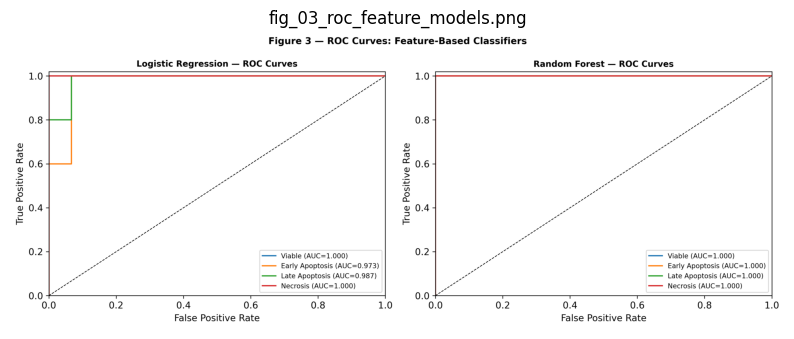

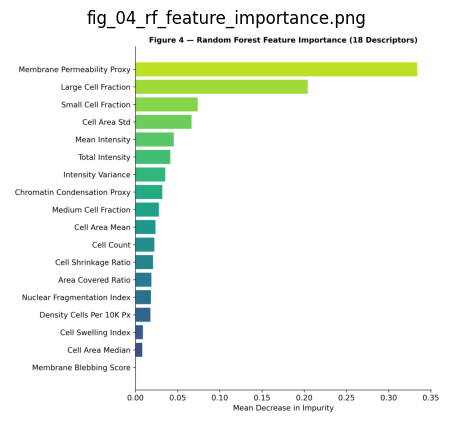

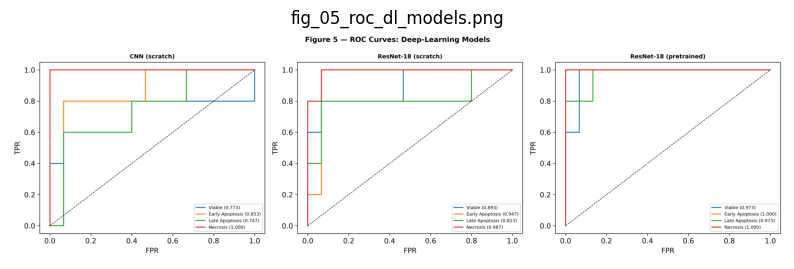

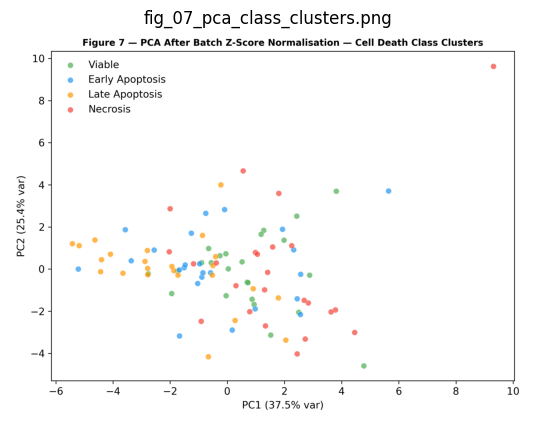

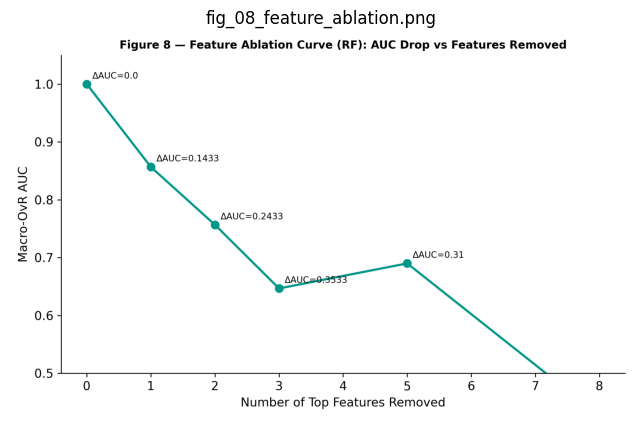

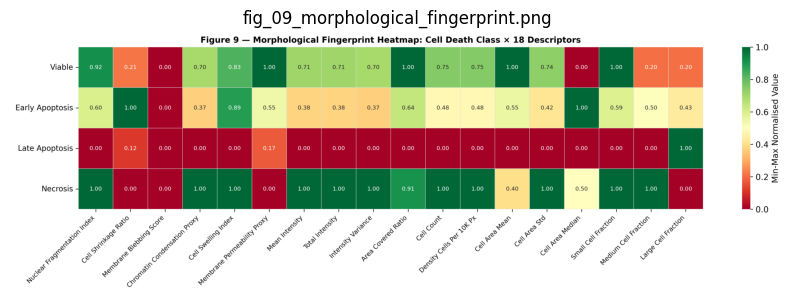

In [9]:
main_figs = [
    'fig_01_pipeline_workflow.png',
    'fig_02_cell_overlays.png',
    'fig_03_roc_feature_models.png',
    'fig_04_rf_feature_importance.png',
    'fig_05_roc_dl_models.png',
    'fig_07_pca_class_clusters.png',
    'fig_08_feature_ablation.png',
    'fig_09_morphological_fingerprint.png',
]
for f in main_figs:
    show_fig(f, f, w=10, h=5)


## Supplementary Figure Panel


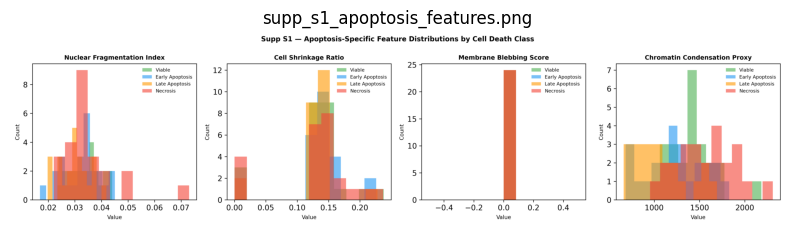

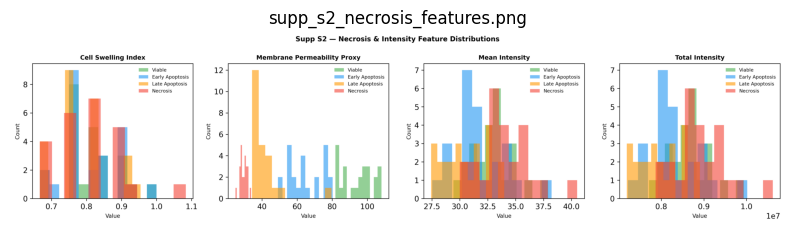

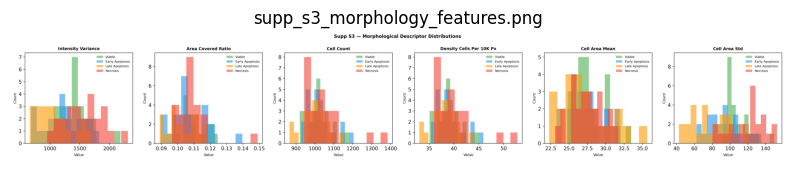

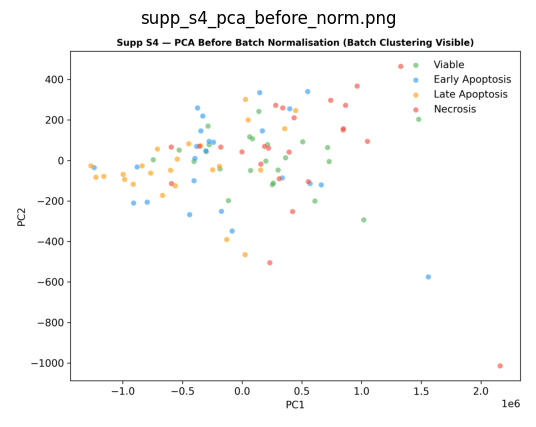

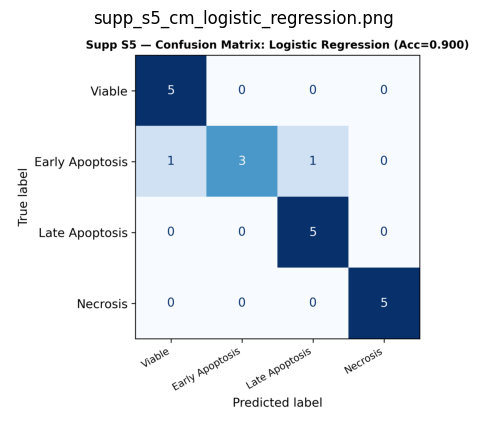

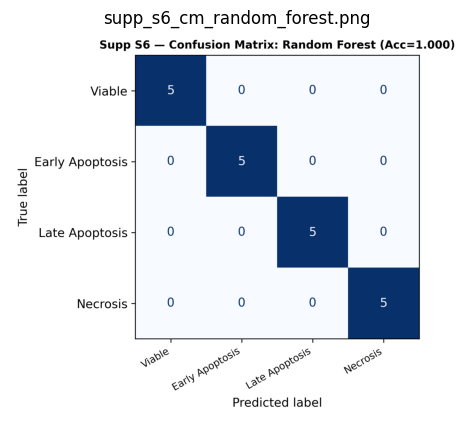

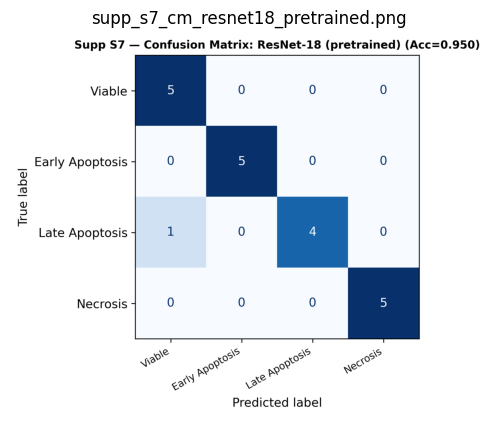

In [10]:
supp_figs = [
    'supp_s1_apoptosis_features.png',
    'supp_s2_necrosis_features.png',
    'supp_s3_morphology_features.png',
    'supp_s4_pca_before_norm.png',
    'supp_s5_cm_logistic_regression.png',
    'supp_s6_cm_random_forest.png',
    'supp_s7_cm_resnet18_pretrained.png',
]
for f in supp_figs:
    show_fig(f, f, w=10, h=5)


## Limitations (Explicit)

1. Pilot-scale dataset size limits statistical reliability.
2. Some inferential outputs require redesign/recomputation before publication-grade interpretation.
3. Dose-response interpretation is constrained when particle size is used as a proxy for dose.
4. Biological claims must track statistically supported features only.


## Action Plan for Publishable Revision

1. Expand dataset by at least one order of magnitude before performance claims.
2. Recompute inferential statistics with valid assumptions and exact/permutation alternatives where appropriate.
3. Add complete Methods and figure legends.
4. Separate feasibility claims (current) from confirmatory claims (future larger cohort).
